## Importing Libraries

In [ ]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score
from skimage.segmentation import slic, mark_boundaries, find_boundaries
from skimage.util import img_as_float

## Download Dataset

In [2]:
path = kagglehub.dataset_download("aniruddhsharma/structural-defects-network-concrete-crack-images")
print("Path to dataset files:", path)

100%|██████████| 506M/506M [00:04<00:00, 130MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/aniruddhsharma/structural-defects-network-concrete-crack-images/versions/1


In [3]:
base_path = path

wall_cracked_dir = os.path.join(base_path, 'Walls', 'Cracked')
wall_noncracked_dir = os.path.join(base_path, 'Walls', 'Non-cracked')

# Get sample image paths
sample_cracked_images = os.listdir(wall_cracked_dir)
sample_noncracked_images = os.listdir(wall_noncracked_dir)

print(f"Number of cracked wall images: {len(sample_cracked_images)}")
print(f"Number of cracked wall images: {len(sample_noncracked_images)}")
print("First 5 image names:", sample_cracked_images[:5])

Number of cracked wall images: 3851
Number of cracked wall images: 14287
First 5 image names: ['7121-227.jpg', '7088-195.jpg', '7085-139.jpg', '7138-101.jpg', '7072-79.jpg']


In [4]:
categories = ['Decks', 'Pavements', 'Walls']
summary = {}

for cat in categories:
    c_dir = os.path.join(base_path, cat, 'Cracked')
    n_dir = os.path.join(base_path, cat, 'Non-cracked')

    c_count = len(os.listdir(c_dir))
    n_count = len(os.listdir(n_dir))
    total = c_count + n_count

    summary[cat] = {
        'Cracked': c_count,
        'Non-Cracked': n_count,
        'Total': total,
        'Crack %': round((c_count / total) * 100, 2)
    }

df_summary = pd.DataFrame(summary).T
print(df_summary)

           Cracked  Non-Cracked    Total  Crack %
Decks       2025.0      11595.0  13620.0    14.87
Pavements   2608.0      21726.0  24334.0    10.72
Walls       3851.0      14287.0  18138.0    21.23


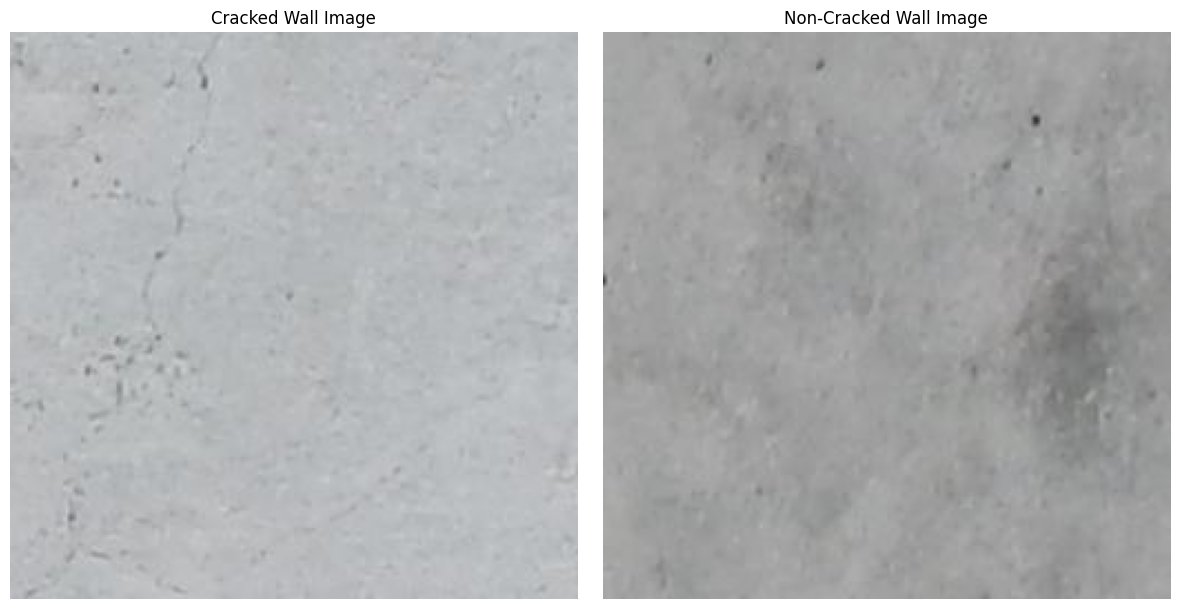

In [5]:
sample_cracked_path = os.path.join(wall_cracked_dir, sample_cracked_images[2])
sample_noncracked_path = os.path.join(wall_noncracked_dir, sample_noncracked_images[0])

# Load and convert cracked image to RGB
cracked_img = cv2.imread(sample_cracked_path)
cracked_img_rgb = cv2.cvtColor(cracked_img, cv2.COLOR_BGR2RGB)

# Load and convert non-cracked image to RGB
noncracked_img = cv2.imread(sample_noncracked_path)
noncracked_img_rgb = cv2.cvtColor(noncracked_img, cv2.COLOR_BGR2RGB)

# Plot both images
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cracked_img_rgb)
plt.title("Cracked Wall Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(noncracked_img_rgb)
plt.title("Non-Cracked Wall Image")
plt.axis("off")

plt.tight_layout()
plt.show()

## Harris Corner Detection

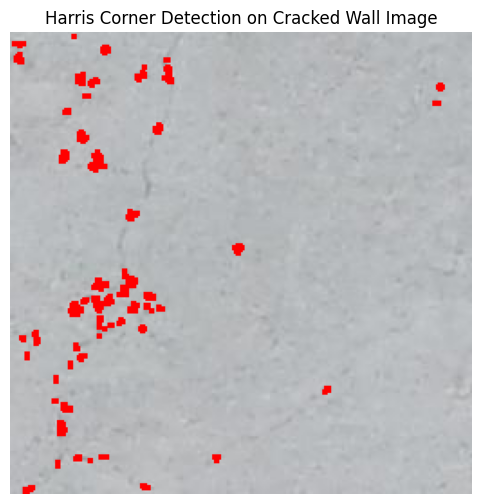

In [6]:
# Reload image in grayscale
gray = cv2.imread(sample_cracked_path, cv2.IMREAD_GRAYSCALE)

# Convert to float32 as required by Harris
gray = np.float32(gray)

# Apply Harris Corner Detector
dst = cv2.cornerHarris(src=gray, blockSize=2, ksize=3, k=0.04)

# Dilate result to mark corners more clearly
dst = cv2.dilate(dst, None)

# Threshold to identify strong corners
img_with_corners = cv2.imread(sample_cracked_path)
img_with_corners[dst > 0.01 * dst.max()] = [0, 0, 255]  # Red dot

# Convert to RGB for Matplotlib
img_rgb = cv2.cvtColor(img_with_corners, cv2.COLOR_BGR2RGB)

# Show result
plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.title("Harris Corner Detection on Cracked Wall Image")
plt.axis("off")
plt.show()

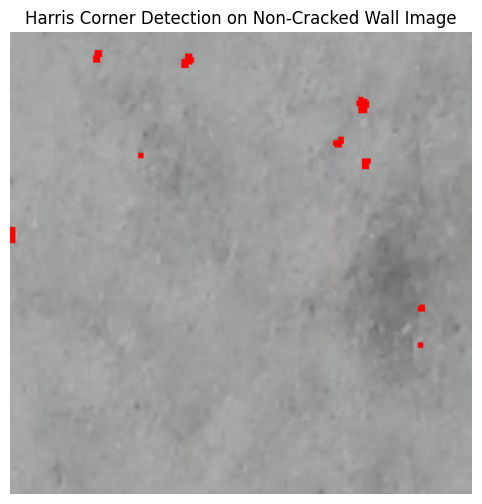

In [7]:
# Reload image in grayscale
gray = cv2.imread(sample_noncracked_path, cv2.IMREAD_GRAYSCALE)

# Convert to float32 as required by Harris
gray = np.float32(gray)

# Apply Harris Corner Detector
dst = cv2.cornerHarris(src=gray, blockSize=2, ksize=3, k=0.04)

# Dilate result to mark corners more clearly
dst = cv2.dilate(dst, None)

# Threshold to identify strong corners
img_with_corners = cv2.imread(sample_noncracked_path)
img_with_corners[dst > 0.01 * dst.max()] = [0, 0, 255]  # Red dot

# Convert to RGB for Matplotlib
img_rgb = cv2.cvtColor(img_with_corners, cv2.COLOR_BGR2RGB)

# Show result
plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.title("Harris Corner Detection on Non-Cracked Wall Image")
plt.axis("off")
plt.show()

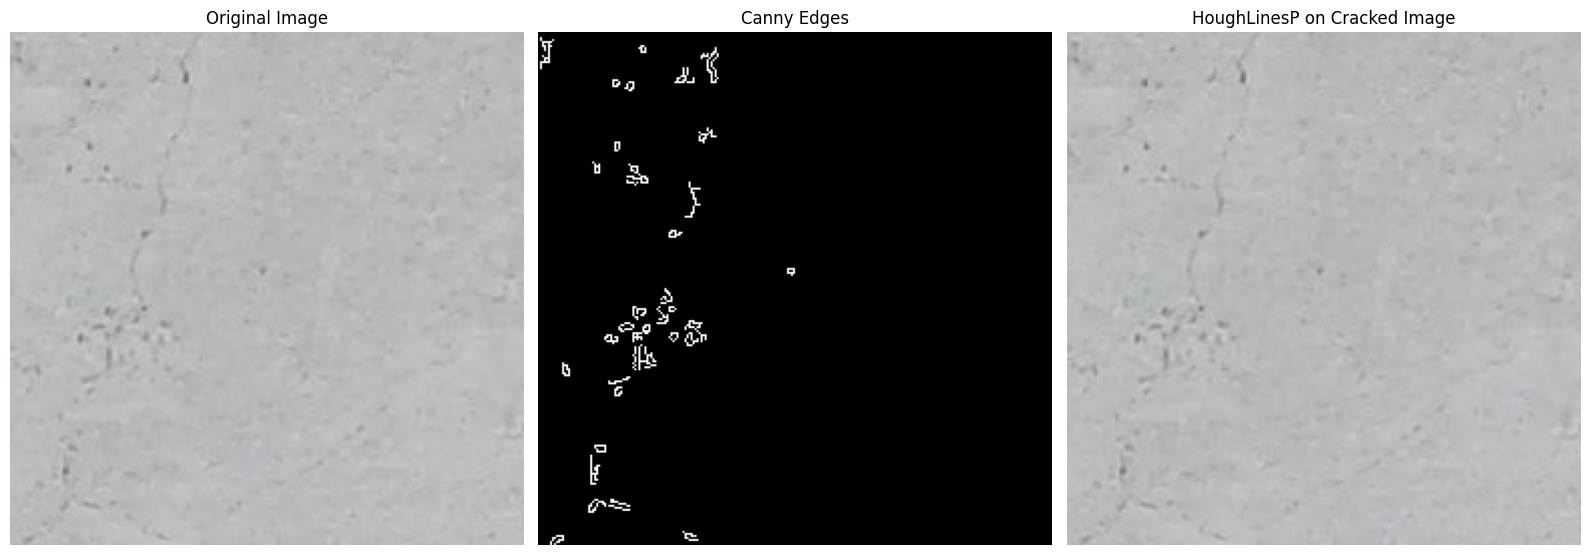

In [8]:
# Load image
img = cv2.imread(sample_cracked_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)



# Canny Edge Detection
edges = cv2.Canny(gray, 50, 150)

# Probabilistic Hough Line Transform
lines = cv2.HoughLinesP(edges,
                        rho=1,
                        theta=np.pi/180,
                        threshold=50,
                        minLineLength=30,
                        maxLineGap=10)

# Draw lines
img_lines = img.copy()
if lines is not None:
    for x1, y1, x2, y2 in lines[:, 0]:
        cv2.line(img_lines, (x1, y1), (x2, y2), (0, 255, 0), 2)

# Plotting
plt.figure(figsize=(16, 8))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(edges, cmap='gray')
plt.title("Canny Edges")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(img_lines, cv2.COLOR_BGR2RGB))
plt.title("HoughLinesP on Cracked Image")
plt.axis("off")

plt.tight_layout()
plt.show()

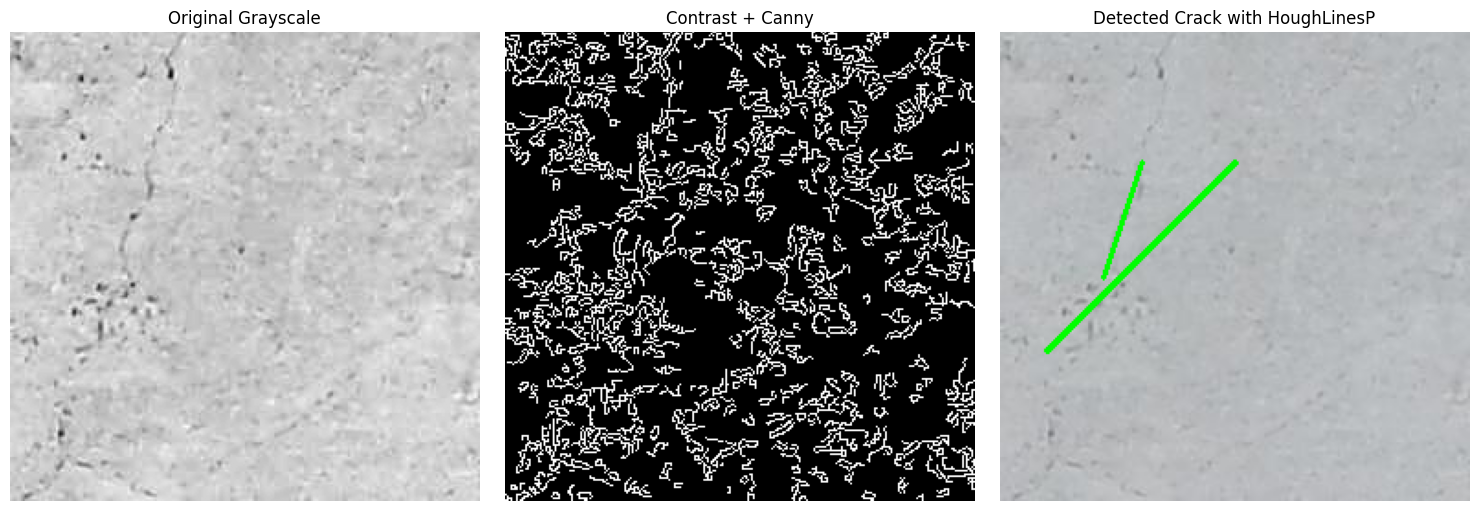

In [9]:
# Apply CLAHE for contrast enhancement
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
contrast_img = clahe.apply(gray)

# Apply Canny edge detection
edges = cv2.Canny(contrast_img, 50, 120)

# Apply HoughLinesP
lines = cv2.HoughLinesP(edges, rho=1, theta=np.pi / 180, threshold=60, minLineLength=60, maxLineGap=6)

# Draw lines
line_img = img.copy()
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(line_img, (x1, y1), (x2, y2), (0, 255, 0), 2)

# Show result
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(gray, cmap='gray')
plt.title("Original Grayscale")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(edges, cmap='gray')
plt.title("Contrast + Canny")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(line_img, cv2.COLOR_BGR2RGB))
plt.title("Detected Crack with HoughLinesP")
plt.axis("off")
plt.tight_layout()
plt.show()

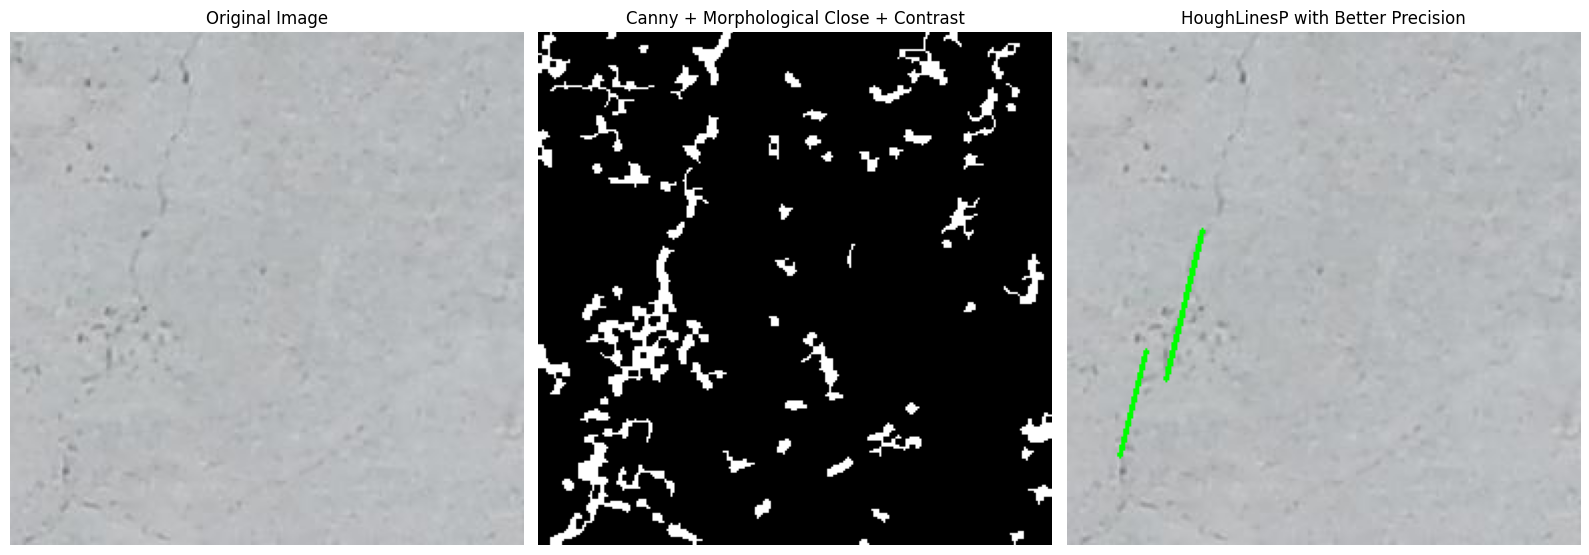

In [10]:

# Step 1: CLAHE with softer contrast boost
clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))
enhanced = clahe.apply(gray)

# Step 2: Gaussian Blur to reduce noise
blurred = cv2.GaussianBlur(enhanced, (3, 3), 0)

# Step 3: Canny Edge Detection (tuned)
edges = cv2.Canny(blurred, 50, 120)

# Step 4: Morphological closing to connect cracks & remove noise
kernel = np.ones((3, 3), np.uint8)
closed_edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

# Step 5: HoughLinesP with tuned params
lines = cv2.HoughLinesP(closed_edges,
                        rho=1,
                        theta=np.pi/180,
                        threshold=65,         # moderate threshold
                        minLineLength=48,     # avoid tiny noise
                        maxLineGap=8)        # still join cracks

# Draw lines
img_lines = img.copy()
if lines is not None:
    for x1, y1, x2, y2 in lines[:, 0]:
        cv2.line(img_lines, (x1, y1), (x2, y2), (0, 255, 0), 2)

# Plotting
plt.figure(figsize=(16, 8))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(closed_edges, cmap='gray')
plt.title("Canny + Morphological Close + Contrast")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(img_lines, cv2.COLOR_BGR2RGB))
plt.title("HoughLinesP with Better Precision")
plt.axis("off")

plt.tight_layout()
plt.show()


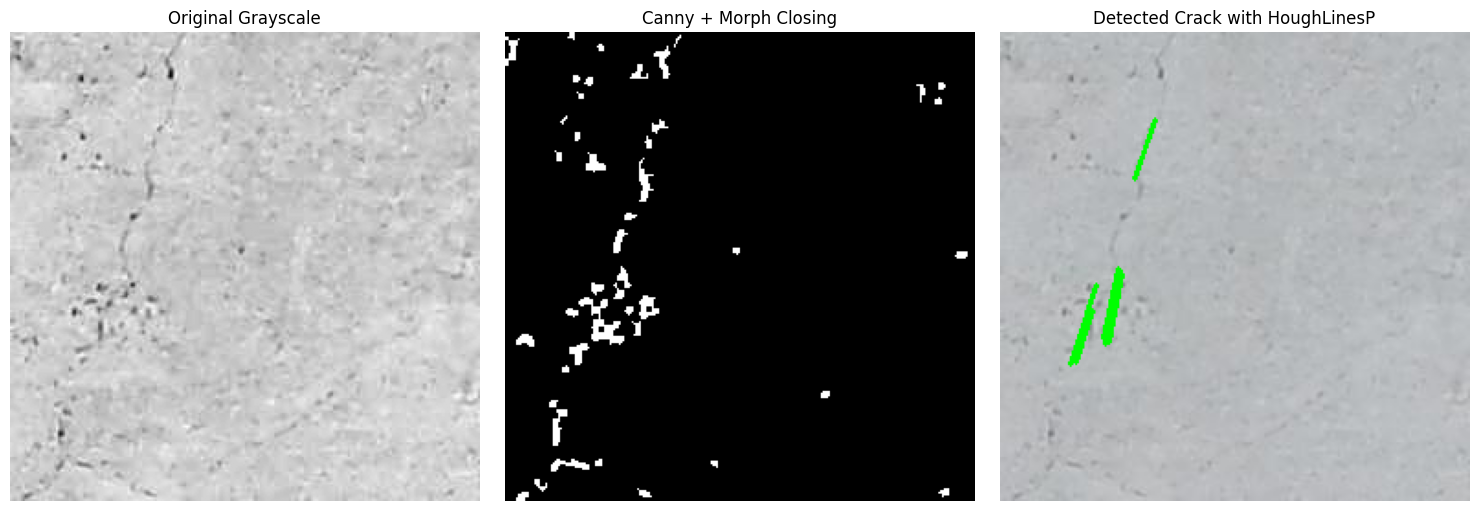

In [11]:
# Canny edge detection
edges = cv2.Canny(gray, 50, 120)

# Morphological closing
kernel = np.ones((3, 3), np.uint8)
closed_edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

# Apply HoughLinesP
lines = cv2.HoughLinesP(closed_edges, rho=1, theta=np.pi / 180, threshold=50, minLineLength=28, maxLineGap=15)

# Draw lines
line_img = img.copy()
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(line_img, (x1, y1), (x2, y2), (0, 255, 0), 2)

# Show result
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(gray, cmap='gray')
plt.title("Original Grayscale")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(closed_edges, cmap='gray')
plt.title("Canny + Morph Closing")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(line_img, cv2.COLOR_BGR2RGB))
plt.title("Detected Crack with HoughLinesP")
plt.axis("off")
plt.tight_layout()
plt.show()

## Evaluation

In [12]:
# Get 1000 random image paths from each
cracked_images = random.sample(os.listdir(wall_cracked_dir), 1000)
noncracked_images = random.sample(os.listdir(wall_noncracked_dir), 1000)

y_true = []
y_pred = []

def process_image(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return 0  # Assume no crack if image can't be loaded

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Canny edge detection
    edges = cv2.Canny(gray, 50, 120)

    # Morphological closing
    kernel = np.ones((3, 3), np.uint8)
    closed_edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

    # Hough Line Transform
    lines = cv2.HoughLinesP(closed_edges, rho=1, theta=np.pi / 180,
                            threshold=50, minLineLength=28, maxLineGap=15)

    return 1 if lines is not None and len(lines) > 0 else 0

# Process cracked images
for img_name in cracked_images:
    img_path = os.path.join(wall_cracked_dir, img_name)
    y_true.append(1)
    y_pred.append(process_image(img_path))

# Process non-cracked images
for img_name in noncracked_images:
    img_path = os.path.join(wall_noncracked_dir, img_name)
    y_true.append(0)
    y_pred.append(process_image(img_path))

# Evaluation
print("Total Images Processed:", len(y_true))
print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall   :", recall_score(y_true, y_pred))
print("F1-Score :", f1_score(y_true, y_pred))


Total Images Processed: 2000
Accuracy : 0.609
Precision: 0.5994525547445255
Recall   : 0.657
F1-Score : 0.6269083969465649


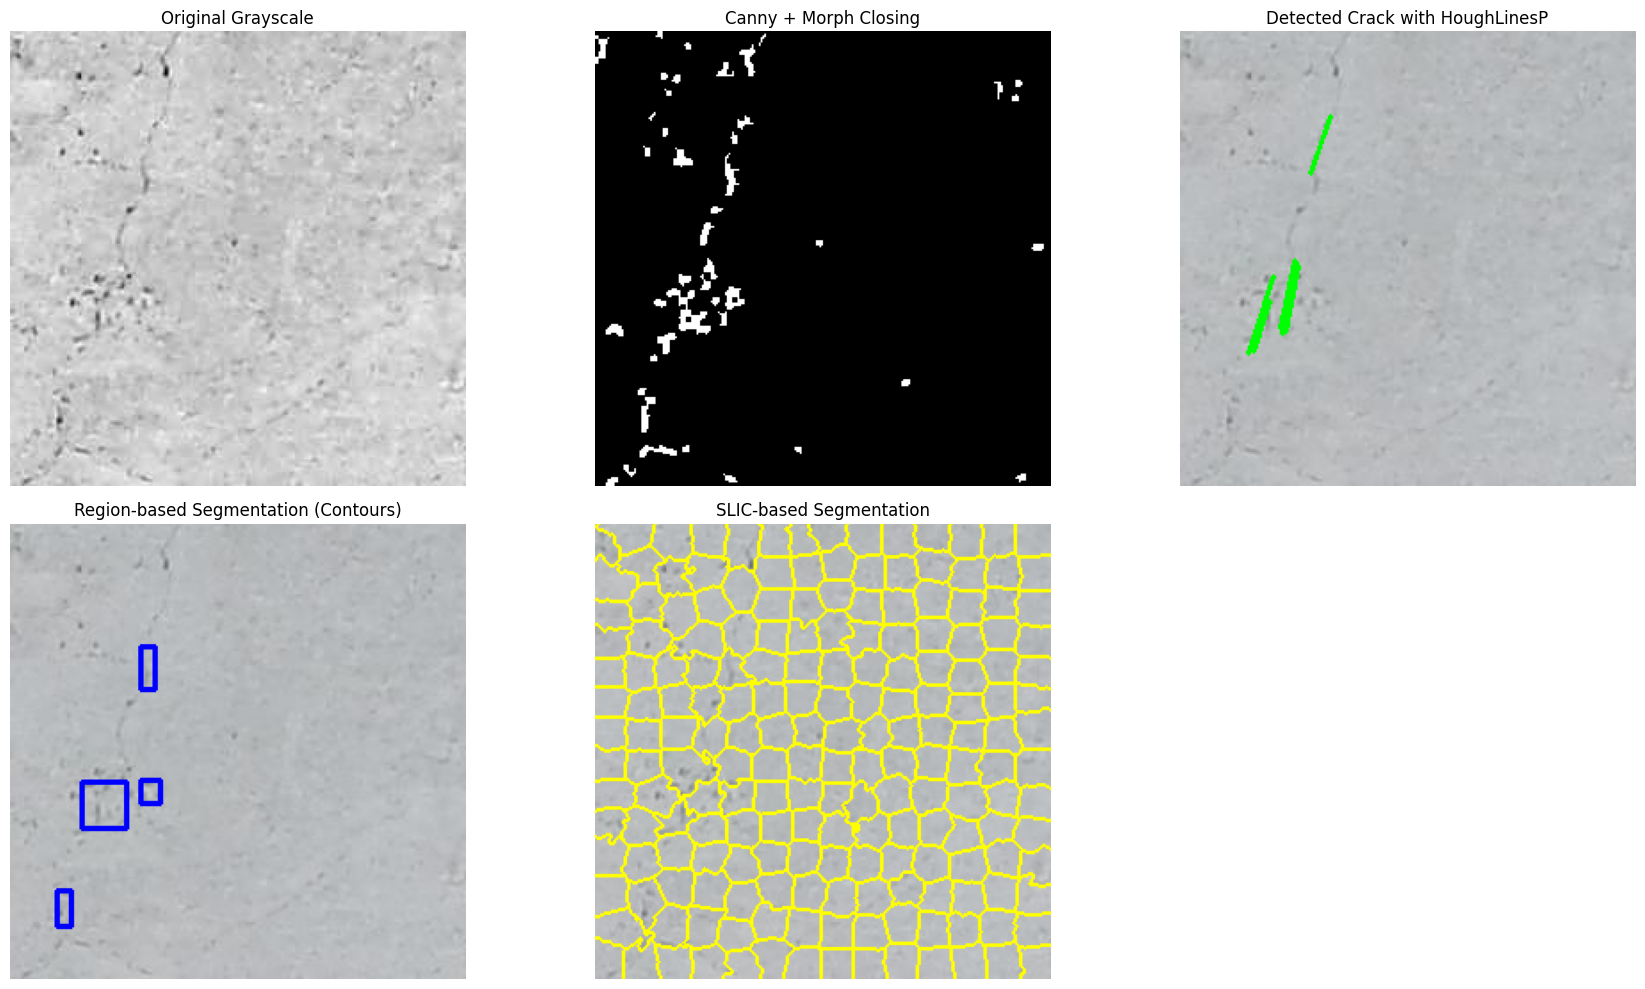

In [13]:
# Canny edge detection
edges = cv2.Canny(gray, 50, 120)

# Morphological closing
kernel = np.ones((3, 3), np.uint8)
closed_edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

# -------------------------------
# Hough LinesP Detection (as provided)
# -------------------------------
lines = cv2.HoughLinesP(closed_edges, rho=1, theta=np.pi/180,
                        threshold=50, minLineLength=28, maxLineGap=15)
line_img = img.copy()
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(line_img, (x1, y1), (x2, y2), (0, 255, 0), 2)

# -------------------------------
# Region-based segmentation using contours
# -------------------------------
# Find contours from the closed edge map
contours, _ = cv2.findContours(closed_edges.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
region_seg_img = img.copy()  # copy for drawing bounding boxes
for cnt in contours:
    area = cv2.contourArea(cnt)
    # Filter out small regions; adjust the area threshold as needed
    if area > 50:
        x, y, w, h = cv2.boundingRect(cnt)
        # Optionally, you can filter on aspect ratio too here
        cv2.rectangle(region_seg_img, (x, y), (x + w, y + h), (255, 0, 0), 2)

# -------------------------------
# SLIC-based segmentation (Superpixels)
# -------------------------------
# Convert image to float in RGB order as required by skimage
img_float = img_as_float(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
# Apply SLIC segmentation; adjust n_segments and compactness to control granularity
segments = slic(img_float, n_segments=200, compactness=10, sigma=1)
# Overlay the boundaries of superpixels on the image
slic_boundaries = mark_boundaries(img_float, segments)

# -------------------------------
# Display all results together
# -------------------------------
plt.figure(figsize=(18, 10))

plt.subplot(2, 3, 1)
plt.imshow(gray, cmap='gray')
plt.title("Original Grayscale")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(closed_edges, cmap='gray')
plt.title("Canny + Morph Closing")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(cv2.cvtColor(line_img, cv2.COLOR_BGR2RGB))
plt.title("Detected Crack with HoughLinesP")
plt.axis("off")

plt.subplot(2, 3, 4)
# Note: region_seg_img is in BGR, so convert to RGB
plt.imshow(cv2.cvtColor(region_seg_img, cv2.COLOR_BGR2RGB))
plt.title("Region-based Segmentation (Contours)")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(slic_boundaries)
plt.title("SLIC-based Segmentation")
plt.axis("off")

plt.tight_layout()
plt.show()


In [16]:
# Get 1000 random image paths from each
cracked_images = random.sample(os.listdir(wall_cracked_dir), 1000)
noncracked_images = random.sample(os.listdir(wall_noncracked_dir), 1000)

y_true = []
y_pred = []

def process_image_region(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return 0  # Assume no crack if image can't be loaded

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Canny edge detection
    edges = cv2.Canny(gray, 50, 120)

    # Morphological closing
    kernel = np.ones((3, 3), np.uint8)
    closed_edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

    # Hough Line Transform
    lines = cv2.HoughLinesP(closed_edges, rho=1, theta=np.pi/180,
                            threshold=50, minLineLength=28, maxLineGap=15)
    hough_detected = lines is not None and len(lines) > 0

    # Region-based segmentation using contours
    contours, _ = cv2.findContours(closed_edges.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    region_detected = False
    for cnt in contours:
        area = cv2.contourArea(cnt)
        # Filter out small noise regions; adjust threshold as needed (e.g., area > 100)
        if area > 100:
            region_detected = True
            break

    # Union logic: if either method indicates a crack, return 1.
    return 1 if (hough_detected or region_detected) else 0

# Process cracked images (true label 1)
for img_name in cracked_images:
    img_path = os.path.join(wall_cracked_dir, img_name)
    y_true.append(1)
    y_pred.append(process_image_region(img_path))

# Process non-cracked images (true label 0)
for img_name in noncracked_images:
    img_path = os.path.join(wall_noncracked_dir, img_name)
    y_true.append(0)
    y_pred.append(process_image_region(img_path))

# Evaluation for Region-based approach
print("Region-based Segmentation + HoughLinesP")
print("Total Images Processed:", len(y_true))
print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall   :", recall_score(y_true, y_pred))
print("F1-Score :", f1_score(y_true, y_pred))


Region-based Segmentation + HoughLinesP
Total Images Processed: 2000
Accuracy : 0.5765
Precision: 0.5555555555555556
Recall   : 0.765
F1-Score : 0.6436684896928901


In [17]:
# Get 1000 random image paths from each
cracked_images = random.sample(os.listdir(wall_cracked_dir), 1000)
noncracked_images = random.sample(os.listdir(wall_noncracked_dir), 1000)

y_true_slic = []
y_pred_slic = []

def process_image_slic(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return 0

    # First, perform the same basic processing for Hough detection:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 120)
    kernel = np.ones((3, 3), np.uint8)
    closed_edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)
    lines1 = cv2.HoughLinesP(closed_edges, rho=1, theta=np.pi/180,
                             threshold=50, minLineLength=28, maxLineGap=15)
    hough_detected = lines1 is not None and len(lines1) > 0

    # Now, perform SLIC segmentation on the original image.
    # Convert image to RGB float (as required by skimage)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_float = img_as_float(img_rgb)
    # Run SLIC with chosen parameters; adjust n_segments for granularity
    segments = slic(img_float, n_segments=200, compactness=10, sigma=1)
    # Extract boundaries from the SLIC segmentation.
    boundaries = find_boundaries(segments, mode='outer').astype(np.uint8) * 255
    # Optionally, you might want to do a bit of morphological filtering on boundaries here.
    # Run Hough Transform on the boundary mask.
    lines2 = cv2.HoughLinesP(boundaries, rho=1, theta=np.pi/180,
                             threshold=50, minLineLength=28, maxLineGap=15)
    slic_detected = lines2 is not None and len(lines2) > 0

    # Union logic: if either Hough on closed_edges or on SLIC boundaries detects a crack, return 1.
    return 1 if (hough_detected or slic_detected) else 0

# Process cracked images (true label 1)
for img_name in cracked_images:
    img_path = os.path.join(wall_cracked_dir, img_name)
    y_true_slic.append(1)
    y_pred_slic.append(process_image_slic(img_path))

# Process non-cracked images (true label 0)
for img_name in noncracked_images:
    img_path = os.path.join(wall_noncracked_dir, img_name)
    y_true_slic.append(0)
    y_pred_slic.append(process_image_slic(img_path))

# Evaluation for SLIC-based approach
print("SLIC-based Segmentation + HoughLinesP")
print("Total Images Processed:", len(y_true_slic))
print("Accuracy :", accuracy_score(y_true_slic, y_pred_slic))
print("Precision:", precision_score(y_true_slic, y_pred_slic))
print("Recall   :", recall_score(y_true_slic, y_pred_slic))
print("F1-Score :", f1_score(y_true_slic, y_pred_slic))


SLIC-based Segmentation + HoughLinesP
Total Images Processed: 2000
Accuracy : 0.5
Precision: 0.5
Recall   : 1.0
F1-Score : 0.6666666666666666
